In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import expm
from qutip import *

# ---------- parameters ----------
wb = 1.0
dw = 0.02
lam = 0.03
Omega = 0.003

kappa = 0.002
gamma = 0.002
gamma_phi = 0.004

n_max = 5
n = 2

# ---------- operators ----------
b = destroy(n_max + 1)
bd = b.dag()
I_ph = qeye(n_max + 1)

s = basis(2,0) * basis(2,1).dag()   # |v><c|
sd = s.dag()
I_qd = qeye(2)

# tensor operators, updating b and bd
b = tensor(I_qd, I_qd, I_qd, I_qd, I_qd, b)
bd = tensor(I_qd, I_qd, I_qd, I_qd, I_qd, bd)
numf = bd*b

s1 = tensor(s, I_qd, I_qd, I_qd, I_qd, I_ph)
s2 = tensor(I_qd, s, I_qd, I_qd, I_qd, I_ph)
s3 = tensor(I_qd, I_qd, s, I_qd, I_qd, I_ph)
s4 = tensor(I_qd, I_qd, I_qd, s, I_qd, I_ph)
s5 = tensor(I_qd, I_qd, I_qd, I_qd, s, I_ph)

sd1 = tensor(sd, I_qd, I_qd, I_qd, I_qd, I_ph)
sd2 = tensor(I_qd, sd, I_qd, I_qd, I_qd, I_ph)
sd3 = tensor(I_qd, I_qd, sd, I_qd, I_qd, I_ph)
sd4 = tensor(I_qd, I_qd, I_qd, sd, I_qd, I_ph)
sd5 = tensor(I_qd, I_qd, I_qd, I_qd, sd, I_ph)

# I'll first just run its evolution then try the plot of g
delta = -n*wb
Di = np.array([-2, -1, 0, 1, 2])*dw + delta

# creating the hamiltonian

H = (
    wb * numf
    + Di[0]*sd1*s1 + Di[1]*sd2*s2 + Di[2]*sd3*s3 + Di[3]*sd4*s4 + Di[4]*sd5*s5
    + (b + bd) * lam * (sd1*s1 + sd2*s2 + sd3*s3 + sd4*s4 + sd5*s5)
    + Omega * (s1 + s2 + s3 + s4 + s5 + sd1 + sd2 + sd3 + sd4 + sd5)
)

# creating the rho superket

n_0 = basis(2,0)
nc_0 = basis(n_max+1, 0)
psi_0 = tensor(n_0, n_0, n_0, n_0, n_0, nc_0)
rho_0 = tensor(psi_0, psi_0)

# creating the Lindbladian

def Lindblad(op):
    I = tensor(I_qd, I_qd, I_qd, I_qd, I_qd, I_ph)
    return 0.5 * (2*tensor(op, op.conj()) - tensor(op.dag()*op, I) - tensor(I, op.trans()*op.conj()))

# L is the final operator, like d|p>/dt = L|p>
I = tensor(I_qd, I_qd, I_qd, I_qd, I_qd, I_ph)
creation_term = -1j * (tensor(H, I) - tensor(I, H.trans()))
cavity_dis_term = kappa * Lindblad(b)
qd_dis_term = gamma * (Lindblad(s1) + Lindblad(s2) + Lindblad(s3) + Lindblad(s4) + Lindblad(s5))
qd_dephase_term = gamma_phi * (
    Lindblad(sd1*s1) + Lindblad(sd2*s2) + Lindblad(sd3*s3) + Lindblad(sd4*s4) + Lindblad(sd5*s5)
)

L = creation_term + cavity_dis_term + qd_dis_term + qd_dephase_term

# Converting to scipy sparse matrix
L_mat = L.data_as('csr_matrix')

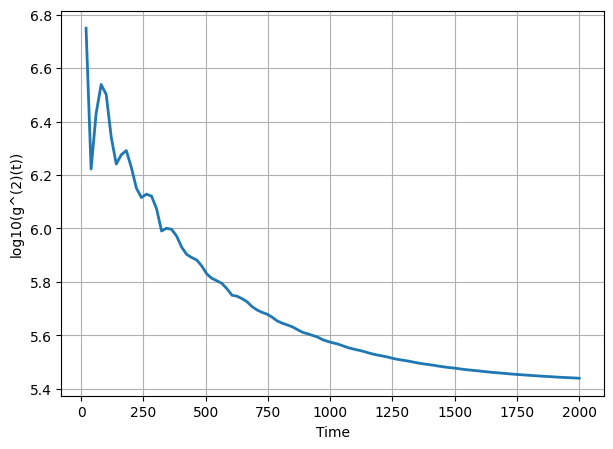

In [9]:
from scipy.sparse.linalg import expm_multiply

# ---------- setup ----------
T_final = 2000
n_steps = 100

times = np.linspace(0, T_final, n_steps)

rho_vec = rho_0.full().flatten()

g2_list = []
n_list = []

# precompute dense operators for observables
num_mat = numf.full()
g2_op = (bd*bd*b*b).full()

# ---------- evolution ----------
rho_t_list = expm_multiply(
    L_mat,
    rho_vec,
    start=0,
    stop=T_final,
    num=n_steps
)

for rho_vec_t in rho_t_list:

    rho_mat = rho_vec_t.reshape((192, 192))

    # clean
    rho_mat = 0.5 * (rho_mat + rho_mat.conj().T)
    rho_mat /= np.trace(rho_mat)

    # observables
    n_expect = np.real(np.trace(rho_mat @ num_mat))
    n_list.append(n_expect)

    if n_expect < 1e-12:
        g2_list.append(np.nan)
    else:
        g2_val = np.real(np.trace(rho_mat @ g2_op)) / (n_expect**2)
        g2_list.append(g2_val)

# ---------- plot ----------
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(times, np.log10(g2_list), lw=2)
plt.ylim
plt.xlabel("Time")
plt.ylabel("log10(g^(2)(t))")
plt.grid(True)
plt.show()